# 5. Does the β trend reproduce on a second model?

Notebook 04 measured, on the square model, that `R` rises and the mate-correlation `ρ` falls as β
grows — so square's `R ≈ 1.04` at β=1 is a property of that **temperature regime**, not of the
single-band square model. That is one model. **One model is an anecdote**, and the claim we want to
make — *`R` grows as you reach deeper into the more interesting low-temperature physics* — is a
statement about the method, not about square.

So this notebook puts a second ladder beside it. FeAs adds something square structurally **could
not** provide:

**Square is sign-free at every β by construction** (nearest-neighbour hopping, bipartite lattice,
half filling), which is exactly why it isolates the correlation-length effect cleanly — and exactly
why it cannot exercise the competing channel. `G = ⟨sign·M⟩/⟨sign⟩`, so a fluctuation in that scalar
denominator gives `δG(k) = −G(k)·δs/s`: a weight `−G(k)` that is itself symmetric, making
**sign-problem noise a fully symmetric channel with mate-correlation exactly 1**. It pushes `ρ` *up*
and `R` toward 1, against the correlation-length effect pushing `ρ` down.

FeAs has `⟨s⟩` falling from 0.998 to 0.148 across its ladder. So this pairing answers a question
neither model answers alone: **when both effects are live, which one wins?**

⚠️ **The two curves are not expected to coincide, and the axes are not directly comparable.** The
models differ in band count, `U`, filling, orbit structure and β range *simultaneously*. The claim
is about **direction and mechanism**, not about the two curves lying on top of each other.

In [1]:
import sys, json
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
import beta_ladder as bl

plt.rcParams['figure.dpi'] = 110
SQ, FE = '#0072B2', '#D55E00'          # Okabe-Ito; CVD-validated pair, fixed per model

L = {'square': json.load(open('../runs/beta_ladder_square.json')),
     'fe_as':  json.load(open('../runs/beta_ladder_fe_as.json'))}
R = {k: v['report']['rungs'] for k, v in L.items()}

for k, v in L.items():
    rr = R[k]
    print(f"{k:>7}: {len(v['runs']):>3} runs | beta {[r['beta'] for r in rr]} | "
          f"{rr[0]['n_seeds']} seeds/rung | {rr[0]['m']} meas/rank | "
          f"spacing violations: {v['report']['seed_spacing_violations'] or 'none'}")

 square: 128 runs | beta [1.0, 2.0, 4.0, 8.0] | 32 seeds/rung | 2048 meas/rank | spacing violations: none
  fe_as: 160 runs | beta [1.0, 2.0, 3.0, 4.0, 5.0] | 32 seeds/rung | 2048 meas/rank | spacing violations: none


## The two ladders

`R` on the full support, with the standard error across base seeds — the project's settled estimator
(the rank bootstrap is optimistic where a sign problem makes per-rank `G` heavy-tailed). `ρ` is the
**mate** correlation, the one that enters `r = m/[1+(m−1)ρ]`.

In [2]:
for k in ('square', 'fe_as'):
    print(f'=== {k} ===')
    print(bl.rung_table(R[k]))
    print()

=== square ===
 beta seeds  m/rank       R (mean +/- sem)           95% t-CI      rho (mates)       <s>   outl
    1    32    2048         1.0414 +/- 0.0015 [1.0383,1.0445]    0.9389 +/- 0.0021   1.00000   1.02
    2    32    2048         1.1406 +/- 0.0029 [1.1347,1.1465]    0.8246 +/- 0.0030   1.00000   1.03
    4    32    2048         1.2122 +/- 0.0065 [1.1990,1.2254]    0.7240 +/- 0.0053   1.00000   1.07
    8    32    2048         1.3429 +/- 0.0088 [1.3249,1.3609]    0.5575 +/- 0.0062   1.00000   1.34

=== fe_as ===
 beta seeds  m/rank       R (mean +/- sem)           95% t-CI      rho (mates)       <s>   outl
    1    32    2048         1.5259 +/- 0.0157 [1.4939,1.5579]    0.5221 +/- 0.0075   0.99805   1.02
    2    32    2048         1.8021 +/- 0.0186 [1.7641,1.8401]    0.4376 +/- 0.0065   0.96094   1.32
    3    32    2048         2.3427 +/- 0.0267 [2.2883,2.3971]    0.2320 +/- 0.0033   0.72266   1.54
    4    32    2048         2.7971 +/- 0.0188 [2.7587,2.8354]    0.1150 +/- 0.

## The overlay

Two panels, not two y-axes on one: `R` and `ρ` live on different scales, and a dual-axis chart would
let the eye read a crossing that is an artifact of the scaling choice. Bands are 95% t-intervals on
the mean across seeds. Endpoints are labelled directly, so identity never rests on colour alone.

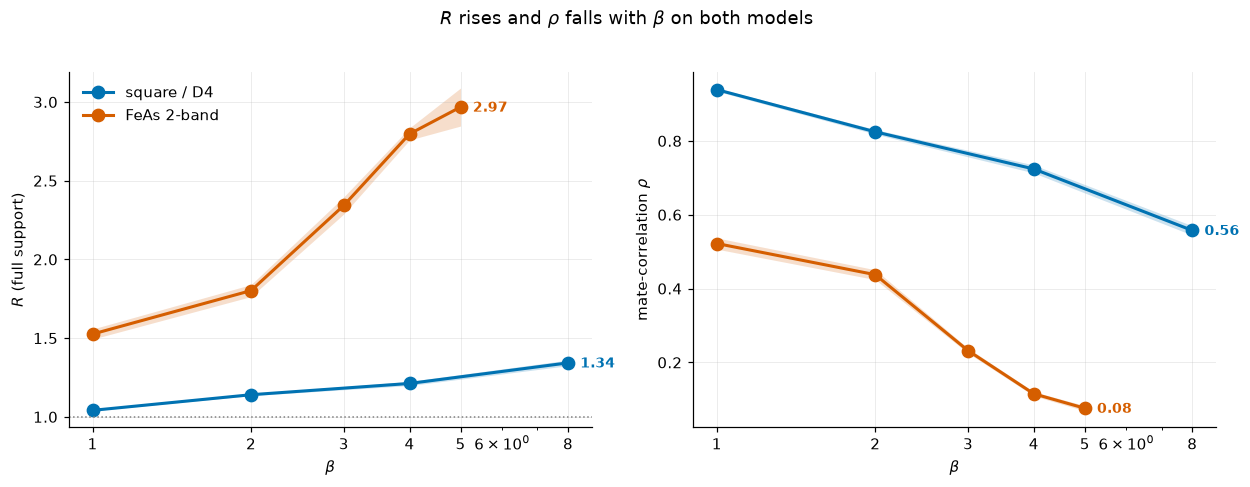

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for ax, key, lab in ((axes[0], 'R_full', r'$R$ (full support)'),
                     (axes[1], 'rho',    r'mate-correlation $\rho$')):
    for name, colour, disp in (('square', SQ, 'square / D4'), ('fe_as', FE, 'FeAs 2-band')):
        rows = R[name]
        b  = np.array([r['beta'] for r in rows], float)
        m  = np.array([r[key]['mean'] for r in rows])
        lo = np.array([r[key]['lo'] for r in rows])
        hi = np.array([r[key]['hi'] for r in rows])
        ax.fill_between(b, lo, hi, alpha=.20, color=colour, lw=0)
        ax.plot(b, m, 'o-', color=colour, lw=2, ms=8, label=disp)
        # Direct-label the endpoint only -- a number on every point is noise, but identity should
        # not depend on the legend alone.
        ax.annotate(f'{m[-1]:.2f}', (b[-1], m[-1]), textcoords='offset points',
                    xytext=(8, -3), color=colour, fontsize=9, fontweight='bold')
    ax.set(xscale='log', xlabel=r'$\beta$', ylabel=lab)
    ax.set_xticks([1, 2, 3, 4, 5, 8]); ax.set_xticklabels(['1', '2', '3', '4', '5', '8'])
    ax.grid(alpha=.25, lw=.6)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
axes[0].axhline(1.0, ls=':', c='0.5', lw=1)
axes[0].legend(frameon=False)
fig.suptitle(r'$R$ rises and $\rho$ falls with $\beta$ on both models', y=1.02)
plt.tight_layout()

## The result the pairing exists to produce

**`ρ` falls monotonically on FeAs even as `⟨s⟩` collapses to 0.148.** Sign noise is a *perfectly*
mate-correlated channel — it should drive `ρ` up. Across the entire range where FeAs is simulable, it
does not win. So the correlation-length mechanism measured on square is not an artifact of working in
a sign-free corner: it survives with the competing channel fully live.

That upgrades the claim from *"measured on square, expected to generalize"* to a two-model result.

In [4]:
print('=== FeAs: the sign channel is live at every rung ===')
print(bl.sign_table(R['fe_as']))
print()
print('=== square: sign-free by construction, verified per rung ===')
print(bl.sign_table(R['square']))

=== FeAs: the sign channel is live at every rung ===
 beta    min <s>    max <s>  sign-free  worst outlier
    1   0.998047   1.000000      False          1.017
    2   0.960938   0.996094      False          1.317
    3   0.722656   0.852539      False          1.544
    4   0.377930   0.543945      False          3.929
    5   0.148438   0.324219      False          6.373

=== square: sign-free by construction, verified per rung ===
 beta    min <s>    max <s>  sign-free  worst outlier
    1   1.000000   1.000000       True          1.016
    2   1.000000   1.000000       True          1.029
    4   1.000000   1.000000       True          1.069
    8   1.000000   1.000000       True          1.341


## Two ceilings, and which one binds

`r = m/[1+(m−1)ρ]` has two limits: an orbit can never beat its size `m`, and as `m → ∞` it tends to
`1/ρ`. So each orbit is capped near **min(m, 1/ρ)** — and *which* ceiling binds tells you what to do
next. A ρ-limited model needs colder physics; an m-limited model needs more symmetry.

Both models start ρ-limited. FeAs does not end that way.

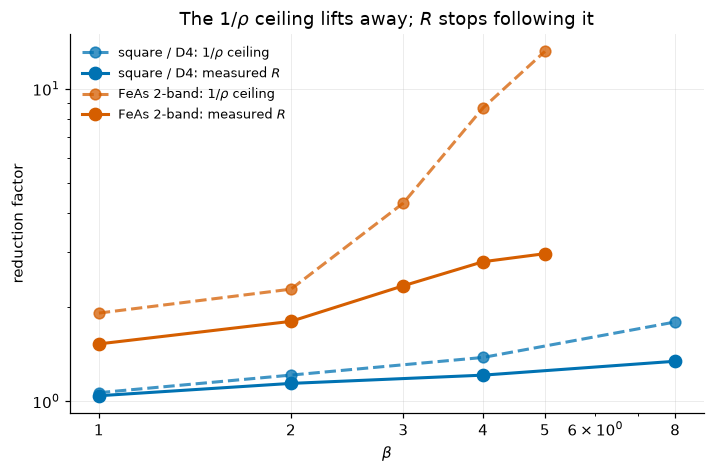

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 4.4))
for name, colour, disp in (('square', SQ, 'square / D4'), ('fe_as', FE, 'FeAs 2-band')):
    rows = R[name]
    b   = np.array([r['beta'] for r in rows], float)
    inv = np.array([1.0 / r['rho']['mean'] for r in rows])
    rr  = np.array([r['R_full']['mean'] for r in rows])
    # rf-string, not f: a bare f-string is not raw, so the notebook's \rho would be eaten as \r.
    ax.plot(b, inv, 'o--', color=colour, lw=2, ms=7, alpha=.75, label=rf'{disp}: $1/\rho$ ceiling')
    ax.plot(b, rr, 'o-', color=colour, lw=2, ms=8, label=f'{disp}: measured $R$')
ax.set(xscale='log', yscale='log', xlabel=r'$\beta$', ylabel='reduction factor')
ax.set_xticks([1, 2, 3, 4, 5, 8]); ax.set_xticklabels(['1', '2', '3', '4', '5', '8'])
ax.grid(alpha=.25, lw=.6)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=8.5)
ax.set_title(r'The $1/\rho$ ceiling lifts away; $R$ stops following it')
plt.tight_layout()

In [6]:
# Where each rung sits between its two ceilings. The m-ceiling is the rho=0 limit of the same
# weighted-harmonic mixture that produces R, so it is the honest "if the physics were perfect" bar.
print(f"{'model':>8} {'beta':>5} {'R':>8} {'1/rho':>8} {'binding ceiling':>16}")
for name in ('square', 'fe_as'):
    for r in R[name]:
        inv = 1.0 / r['rho']['mean']
        print(f"{name:>8} {r['beta']:>5g} {r['R_full']['mean']:>8.3f} {inv:>8.2f} "
              f"{('rho (physics)' if inv < 3.6 else 'm (geometry)'):>16}")

   model  beta        R    1/rho  binding ceiling
  square     1    1.041     1.07    rho (physics)
  square     2    1.141     1.21    rho (physics)
  square     4    1.212     1.38    rho (physics)
  square     8    1.343     1.79    rho (physics)
   fe_as     1    1.526     1.92    rho (physics)
   fe_as     2    1.802     2.28    rho (physics)
   fe_as     3    2.343     4.31     m (geometry)
   fe_as     4    2.797     8.70     m (geometry)
   fe_as     5    2.968    13.18     m (geometry)


## Honesty item: `w_null` grows, and it is part of the trend

`R_full = R_non-null/(1 − w_null)`, where `w_null` is the forced-null share of raw variance —
symmetry-*forbidden* entries whose noise symmetrization annihilates completely. It is a real benefit
a user experiences, but it is **not** the mate-decorrelation mechanism, and it grows with β. So a
rising `R_full` mixes two effects, and the Conventions require reporting both columns in exactly this
cross-model setting.

In [7]:
for k in ('square', 'fe_as'):
    print(f'=== {k} ===')
    print(bl.support_table(R[k]))
    print()

fe = R['fe_as']
f0, f1 = fe[0], fe[-1]
gf = f1['R_full']['mean'] / f0['R_full']['mean']
gn = f1['R_nonnull']['mean'] / f0['R_nonnull']['mean']
print(f"FeAs beta=1 -> {f1['beta']:g}:  R_full x{gf:.3f}   R_non-null x{gn:.3f}"
      f"   -> {100*(gf-gn)/(gf-1):.0f}% of the rise is w_null, not mechanism")

=== square ===
 beta               R full           R non-null             w_null
    1       1.0414 +/- 0.0015       1.0414 +/- 0.0015     0.0000 +/- 0.0000
    2       1.1406 +/- 0.0029       1.1406 +/- 0.0029     0.0000 +/- 0.0000
    4       1.2122 +/- 0.0065       1.2122 +/- 0.0065     0.0000 +/- 0.0000
    8       1.3429 +/- 0.0088       1.3429 +/- 0.0088     0.0000 +/- 0.0000

=== fe_as ===
 beta               R full           R non-null             w_null
    1       1.5259 +/- 0.0157       1.4783 +/- 0.0145     0.0310 +/- 0.0007
    2       1.8021 +/- 0.0186       1.6841 +/- 0.0168     0.0654 +/- 0.0010
    3       2.3427 +/- 0.0267       2.0791 +/- 0.0232     0.1124 +/- 0.0013
    4       2.7971 +/- 0.0188       2.3721 +/- 0.0220     0.1519 +/- 0.0055
    5       2.9679 +/- 0.0592       2.5102 +/- 0.0446     0.1531 +/- 0.0030

FeAs beta=1 -> 5:  R_full x1.945   R_non-null x1.698   -> 26% of the rise is w_null, not mechanism


## Controls

The frequency window shrinks in absolute units as β grows (`sp-fermionic-frequencies` is fixed while
Matsubara spacing is `π/β`), so each rung sums `R` over a different slice — harmless only if `r` is
flat in ω, which is measured per rung rather than inherited from β=1. And the per-orbit law is the
free contamination detector: measured vs predicted `r` diverges exactly when one rank's near-zero
sign dominates the variance sum.

In [8]:
for k in ('square', 'fe_as'):
    print(f'=== {k}: r vs omega ===')
    print(bl.omega_table(R[k]))
    print()
print('=== FeAs: per-orbit law, worst gap per rung ===')
for r in R['fe_as']:
    print(f"  beta={r['beta']:g}  max|r - r_pred| over orbits = "
          f"{max(o['max_abs_gap'] for o in r['orbits']):.3g}")

=== square: r vs omega ===
 beta  runs         slope per step      drift across window   verdict
    1    32      -1.40e-18 +/- 3.0e-18           0.0000% +/- 0.0000%      flat
    2    32      -4.72e-18 +/- 2.4e-18           0.0000% +/- 0.0000%      flat
    4    32      -3.62e-18 +/- 1.5e-18           0.0000% +/- 0.0000%      flat
    8    32      -3.46e-18 +/- 9.2e-19           0.0000% +/- 0.0000%      flat

=== fe_as: r vs omega ===
 beta  runs         slope per step      drift across window   verdict
    1    32      -6.94e-18 +/- 1.0e-17           0.0000% +/- 0.0000%      flat
    2    32      -4.92e-18 +/- 7.5e-18           0.0000% +/- 0.0000%      flat
    3    32      -1.23e-18 +/- 6.3e-18           0.0000% +/- 0.0000%      flat
    4    32      -3.28e-18 +/- 2.7e-18           0.0000% +/- 0.0000%      flat
    5    32      -2.42e-18 +/- 1.7e-18           0.0000% +/- 0.0000%      flat

=== FeAs: per-orbit law, worst gap per rung ===
  beta=1  max|r - r_pred| over orbits = 0.0116

## What this establishes, and what it does not

**Establishes.** The β trend reproduces on a second, structurally different model: FeAs `R` rises
`1.526 ± 0.016 → 2.968 ± 0.059` while `ρ` falls `0.522 → 0.076` over β=1→5, both monotone and
resolved against across-seed scatter (`ΔR = +1.442 [+1.322, +1.561]`). Critically, this happens with
a **live sign problem** — `⟨s⟩` falls to 0.148 — so the perfectly-mate-correlated sign channel loses
to the correlation-length effect across the whole simulable range. The mechanism measured on square
is not an artifact of a sign-free corner.

**Also establishes a limit, which is the more useful half.** `R` is *saturating*: FeAs's steps are
`+0.276, +0.541, +0.454, +0.171`. And it is the **orbit-size ceiling** doing it, not the sign
channel — `ρ` is still falling, and by β=5 `1/ρ = 13.2` against an m-ceiling of ~3.7. **FeAs ends the
ladder m-limited**: the physics is delivering decorrelation that the 4×4 geometry cannot cash in. The
implication is concrete — at that point more symmetry (bigger cluster, larger point group, more
equivalent bands) buys more than colder physics does.

**Does not establish.** Where the sign channel finally wins. It must eventually — as `⟨s⟩ → 0` the
noise is *all* symmetric channel and `R → 1` — but FeAs at β=5 is already at the edge of
measurability (outlier index 6.4, the across-seed SEM tripling), and nothing here locates the
turnover. Shallow scouting at β=6 appeared to show one; it was contamination, not physics.

**Does not establish causation between the models either.** Square and FeAs differ in band count,
`U`, filling and orbit structure simultaneously, so the gap between the curves cannot be attributed
to any single cause. The mechanism is measured; the attribution is not. That is what ROADMAP task 4's
one-axis-at-a-time sweep is for.

**Scope, unchanged.** `Var(G)` for a single-iteration estimator on a 4×4 cluster, plain DCA, CT-AUX
at the bare bath. Observable-level variance stays out of scope. Note CT-AUX drops `J`/`Jp`, so FeAs
runs here as an Ising-Hund density-density model.